# 1.Business Analysis: Are Discounts Beneficial?

The objective of this analysis is to evaluate whether offering discounts benefits Eniac's business. Before analyzing the impact of discounts, it is important to understand the characteristics of the dataset, including its time coverage, revenue, sales evolution, and product performance.

#2. Load libraries and data

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
pd.set_option("display.max_columns", None)

path = "/content/drive/MyDrive/Project Eniac/Data/Data_clean/"

df =pd.read_csv(path + "discount_dataset.csv",
                parse_dates=["date"]
)

products = pd.read_csv(
    path + "products_clean.csv"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
products = products[
    ["sku", "name", "type"]
]

In [33]:
df = df.merge(
    products,
    on="sku",
    how="left"
)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203582 entries, 0 to 203581
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                203582 non-null  int64         
 1   id_order          203582 non-null  int64         
 2   product_id        203582 non-null  int64         
 3   product_quantity  203582 non-null  int64         
 4   sku               203582 non-null  object        
 5   unit_price        203582 non-null  float64       
 6   date              203582 non-null  datetime64[ns]
 7   unit_price_total  203582 non-null  float64       
 8   price             203582 non-null  float64       
 9   discount_amount   203582 non-null  float64       
 10  discount_pct      203582 non-null  float64       
 11  name              203582 non-null  object        
 12  type              203582 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(4), object(3)
memor

###To make the analysis more informative, the cleaned products dataset was merged with the sales dataset using the sku identifier. This allows each transaction to include the corresponding product name and product type, making the results easier to interpret in subsequent analyses.

In [35]:
df.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total,price,discount_amount,discount_pct,name,type
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19,18.99,34.99,16.00,45.73,Otterbox iPhone Case Symmetry 2.0 SE / 5s / 5 ...,11865403
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45,399.00,429.00,30.00,6.99,"27UD58-B LG Monitor 27 ""4K UHD DisplayPort",1296
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57,474.05,699.00,224.95,32.18,Parrot Bebop 2 White + Command FLYPAD and FPV ...,11905404
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40,68.39,79.00,10.61,13.43,"Blue WD 2TB Hard Drive 35 ""Mac and PC",12655397
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38,23.74,29.90,6.16,20.60,Gray Bluetooth Speaker JBL GO,5398


## 3.1 What is the time period that the dataset covers?

Before analyzing revenue and discounts, it is important to understand the time span covered by the dataset.

In [36]:
start_date = df["date"].min()
end_date = df["date"].max()
duration = (end_date - start_date).days


print(f"Start date: {start_date:%Y-%m-%d}")
print(f"End date: {end_date:%Y-%m-%d}")

print(f'Dataset covers {duration} days.')

Start date: 2017-01-01
End date: 2018-03-14
Dataset covers 437 days.


## 3.2 What is the overall revenue for that period?

To understand the scale of the business, we first calculate the total revenue generated during the period covered by the dataset.

In [37]:
total_revenue = df["unit_price_total"].sum()
total_orders = df["id_order"].nunique()
total_products = df["sku"].nunique()
total_units = df["product_quantity"].sum()
average_order_value = total_revenue / total_orders

print(f"Total revenue       : €{total_revenue:,.2f}")
print(f"Total orders        : {total_orders:,}")
print(f"Unique products sold: {total_products:,}")
print(f"Units sold          : {total_units:,}")
print(f"Average order value : €{average_order_value:,.2f}")

Total revenue       : €35,400,046.11
Total orders        : 161,728
Unique products sold: 6,457
Units sold          : 231,319
Average order value : €218.89


##3.3 Are there seasonal patterns in the evolution of sales?

###3.3.1 Monthly Revenue

In [38]:
monthly_revenue = (
    df
    .set_index("date")
    .resample("ME")["unit_price_total"]
    .sum()
)

monthly_revenue

,unit_price_total
date,
2017-01-31,1874823.91
2017-02-28,1444535.99
2017-03-31,1322641.37
2017-04-30,1439103.47
2017-05-31,1471990.74
2017-06-30,1505973.17
2017-07-31,2125568.56
2017-08-31,1538580.14
2017-09-30,1874534.90


###3.3.1 Monthly Revenue Trend

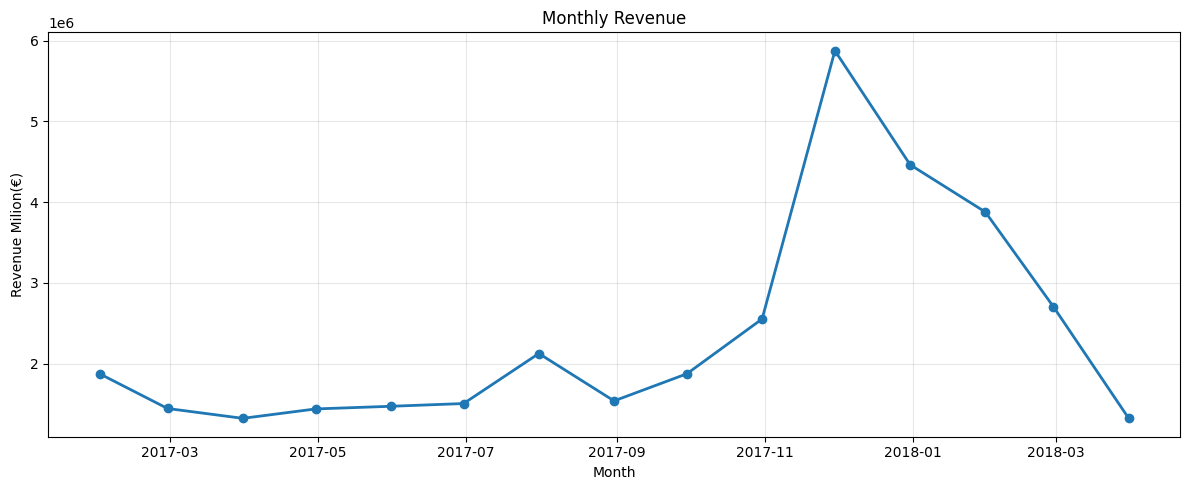

In [39]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue Milion(€)")


plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

Monthly revenue remained relatively stable throughout most of 2017, fluctuating between approximately €1.3M and €2.1M.

A significant increase occurred in November 2017, when revenue reached nearly €5.9M, followed by another strong month in December. These peaks are consistent with major seasonal shopping events such as Black Friday and Christmas.

After the holiday season, revenue gradually declined, suggesting that sales are influenced by seasonal demand rather than maintaining a constant level throughout the year.

###3.3.2 Monthly Orders

In [40]:
monthly_orders = (
    df
    .set_index("date")
    .resample("ME")["id_order"]
    .nunique()
)

monthly_orders

,id_order
date,
2017-01-31,14640
2017-02-28,9371
2017-03-31,8019
2017-04-30,7515
2017-05-31,7344
2017-06-30,7085
2017-07-31,10275
2017-08-31,7605
2017-09-30,8345


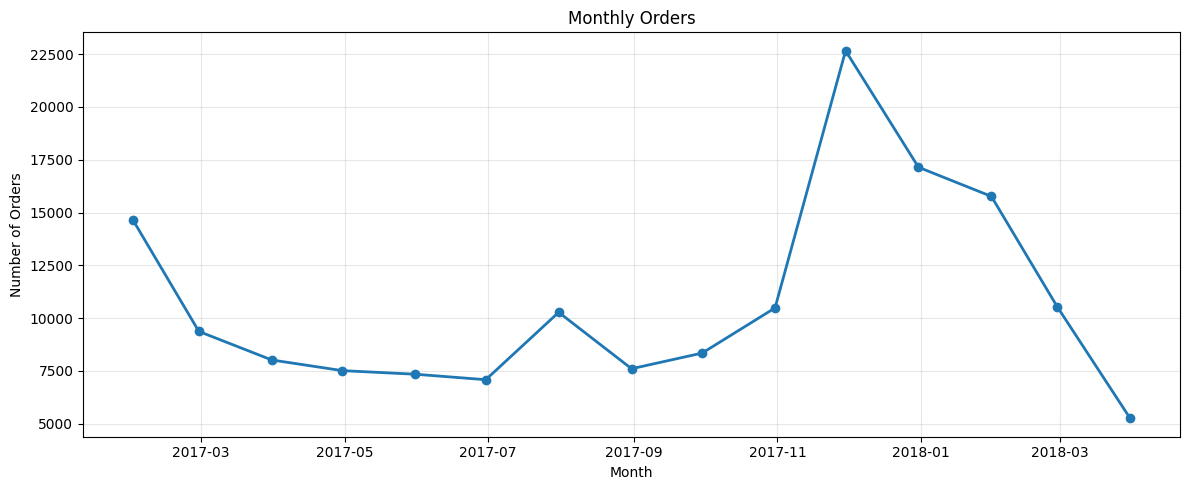

In [41]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")


plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

The number of orders closely followed the revenue trend. Both reached their highest levels in November and remained high in December, indicating a strong seasonal effect during the holiday shopping period.

This suggests that the increase in revenue was mainly driven by a higher number of orders. The next step is to investigate whether discounts contributed to this seasonal growth.

##3.4 What are the most sold products?

In [42]:
top_products = (
    df.groupby("name", as_index=False)["product_quantity"]
      .sum()
      .sort_values("product_quantity", ascending=False)
      .head(10)
)

top_products

,name,product_quantity
1895,IPhone AppleCare Protection Plan,5570
256,Apple Lightning Cable Connector to USB 1m Whit...,2337
4753,"Red 4TB WD 35 ""Mac PC hard drive and NAS",1828
154,AirPods Apple Bluetooth Headset for iPhone iPa...,1661
1403,EarPods Apple Headphones with Remote and Mic (...,1618
4824,Samsung 850 EVO SSD Disk 500GB,1345
618,Apple iPhone 32GB Space Gray,1171
327,Apple Pencil,1114
1158,Crucial MX300 525GB SSD Disk,1113
6011,"WD Red 3TB 35 ""Mac PC hard drive and NAS",1048


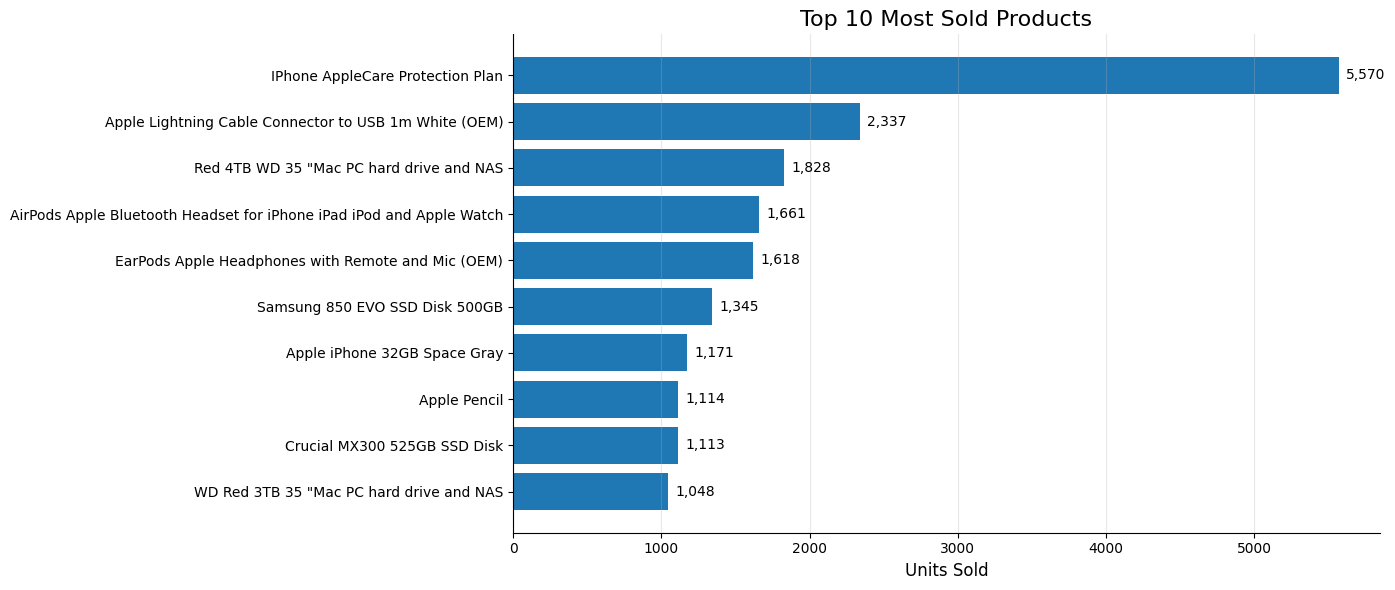

In [43]:
plt.figure(figsize=(14, 6))

bars = plt.barh(
    top_products["name"],
    top_products["product_quantity"]
)


for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Most Sold Products", fontsize=16)
plt.xlabel("Units Sold", fontsize=12)
plt.ylabel("")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

##3.5 Products generating the most revenue

In [44]:
top_revenue = (
    df.groupby("name", as_index=False)["unit_price_total"]
      .sum()
      .sort_values("unit_price_total", ascending=False)
      .head(10)
)

top_revenue

,name,unit_price_total
672,Apple iPhone 8 Plus 64GB Gold,750258.56
624,Apple iPhone 64GB Space Gray 8,587757.54
674,Apple iPhone 8 Plus 64GB Space Gray,544797.75
286,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",475077.70
618,Apple iPhone 32GB Space Gray,422910.77
619,Apple iPhone 6 32GB Space Gray,375354.65
620,Apple iPhone 64GB Gold 8,370322.42
673,Apple iPhone 8 Plus 64GB Silver,358153.98
2188,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",353538.43
1895,IPhone AppleCare Protection Plan,312303.18


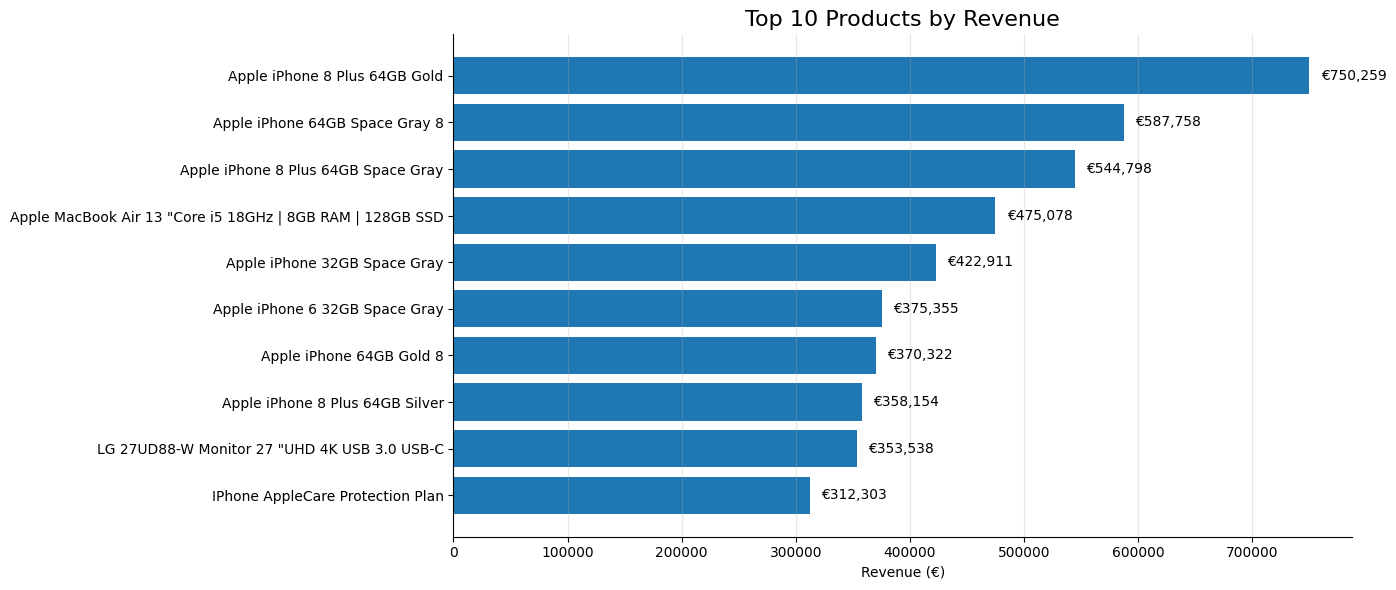

In [45]:
plt.figure(figsize=(14,6))

bars = plt.barh(
    top_revenue["name"],
    top_revenue["unit_price_total"]
)

# Add revenue labels
for bar in bars:
    plt.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height()/2,
        f"€{bar.get_width():,.0f}",
        va="center",
        fontsize=10
    )

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (€)")
plt.ylabel("")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

#4. Discount Analysis

###4.1 How many products are discounted?

In [46]:
discounted_products = df.loc[df["discount_pct"] > 0, "sku"].nunique()

total_products = df["sku"].nunique()

discount_share = discounted_products / total_products * 100

print(f"Products sold: {total_products:,}")
print(f"Products sold with a discount: {discounted_products:,}")
print(f"Share of discounted products: {discount_share:.1f}%")

Products sold: 6,457
Products sold with a discount: 6,284
Share of discounted products: 97.3%


###4.2 Distribution of discounts




In [47]:
df["discount_pct"].describe()

,discount_pct
count,203582.000000
mean,20.976426
std,18.615113
min,0.000000
25%,8.000000
50%,16.670000
75%,27.280000
max,99.910000


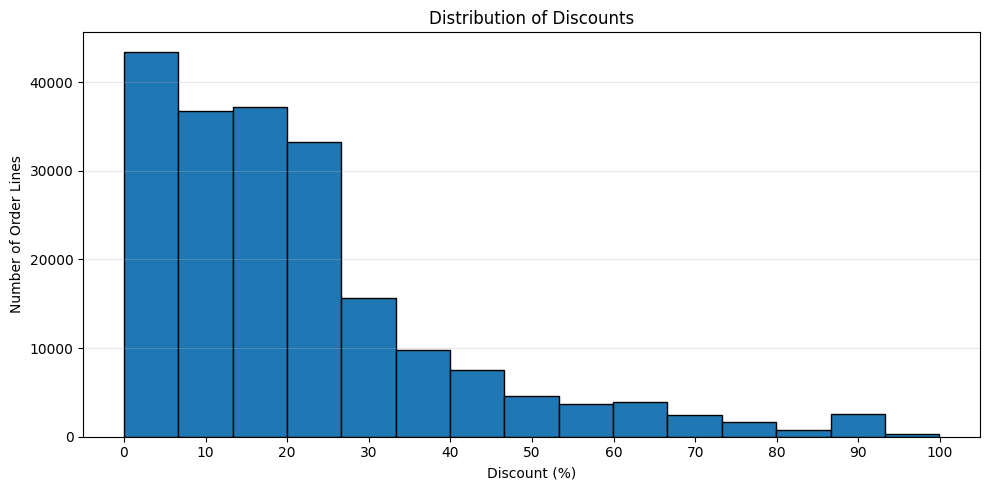

In [48]:
plt.figure(figsize=(10,5))

plt.hist(
    df["discount_pct"],
    bins=15,           # менше стовпчиків
    edgecolor="black"
)

plt.title("Distribution of Discounts")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Order Lines")

plt.xticks(range(0, 101, 10))   # показувати 0,10,20...100
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

Most discounts are between 10% and 30%. The average discount is around 21%, while very high discounts are much less common.

This shows that Eniac usually offers moderate discounts instead of large price reductions.

###4.3 Average Discount Over Time

In [49]:
monthly_discount = (
    df
    .set_index("date")
    .resample("ME")["discount_pct"]
    .mean()
)

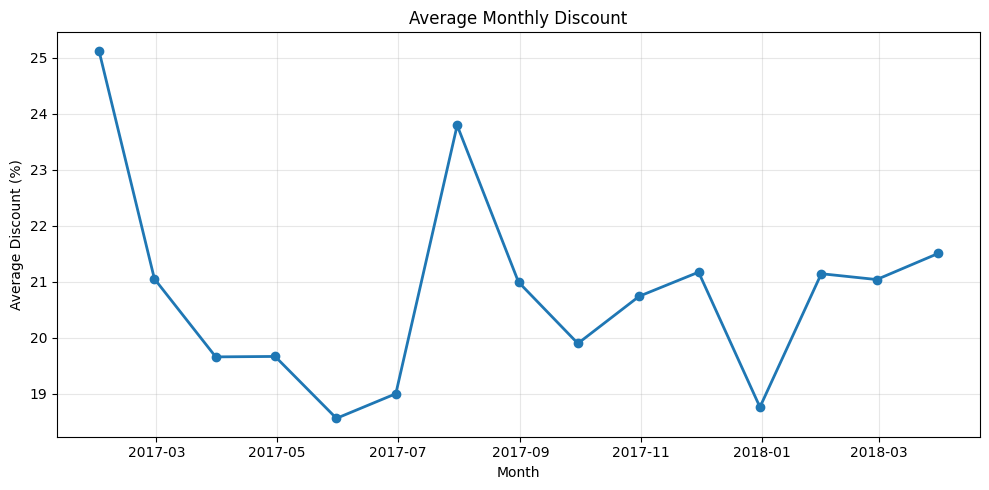

In [50]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_discount.index,
    monthly_discount.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Discount")
plt.xlabel("Month")
plt.ylabel("Average Discount (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

There is a higher average discount at the beginning of 2017 (~25%).
There is also a small peak in August.
But in general, most months are in the range of 19–21%.
Therefore, it cannot be said that the company significantly changed its discount policy during the year.

###4.4 Revenue with and without discounts

In [51]:
discount_revenue = df.loc[df["discount_pct"] > 0, "unit_price_total"].sum()

regular_revenue = df.loc[df["discount_pct"] == 0, "unit_price_total"].sum()

print(f"Revenue with discounts: €{discount_revenue:,.2f}")
print(f"Revenue without discounts: €{regular_revenue:,.2f}")

Revenue with discounts: €33,639,164.30
Revenue without discounts: €1,760,881.81


Text(0.5, 1.0, 'Revenue')

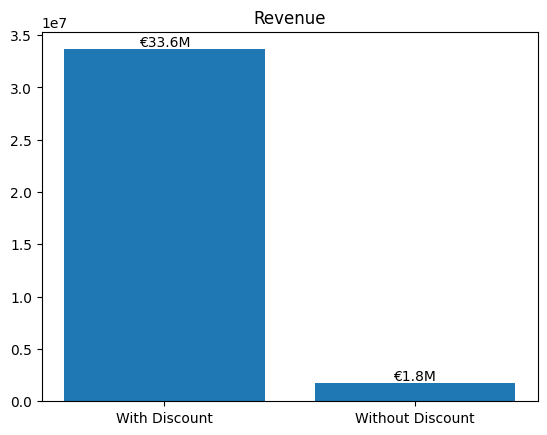

In [52]:
bars = plt.bar(
    ["With Discount", "Without Discount"],
    [discount_revenue, regular_revenue]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"€{height/1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )
plt.title("Revenue")

###4.5 Average Revenue by Transaction

In [53]:
discount_bins = [0, 10, 20, 30, 40, 50, 100]
discount_labels = ["0–10%", "10–20%", "20–30%", "30–40%", "40–50%", "50%+"]

df["discount_group"] = pd.cut(
    df["discount_pct"],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True
)

In [54]:
revenue_by_discount = (
    df.groupby("discount_group", observed=True)["unit_price_total"]
      .mean()
      .reset_index()
)

revenue_by_discount

,discount_group,unit_price_total
0,0–10%,276.858774
1,10–20%,180.032229
2,20–30%,129.277058
3,30–40%,80.352247
4,40–50%,48.953116
5,50%+,46.230714


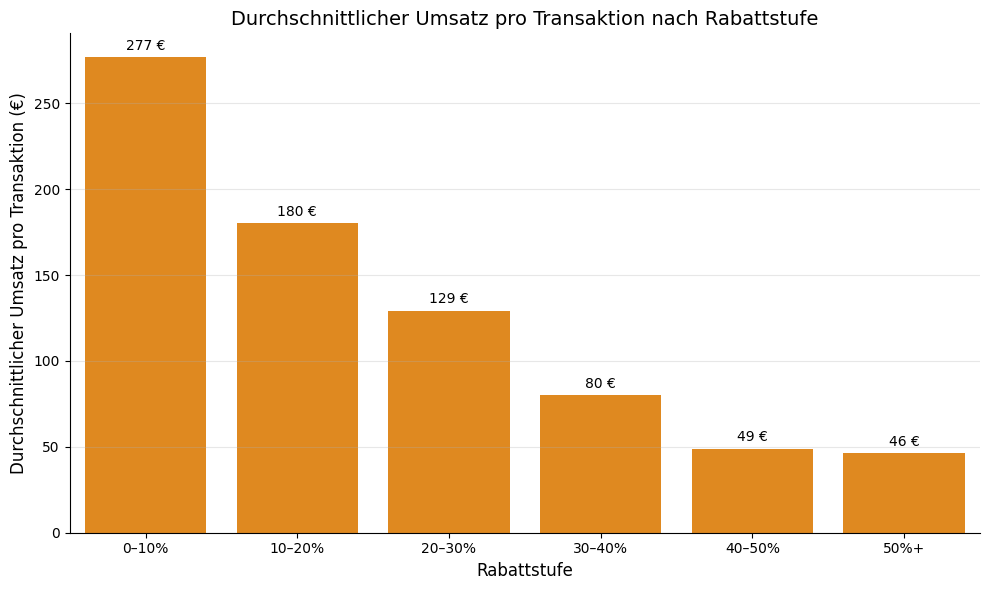

In [55]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=revenue_by_discount,
    x="discount_group",
    y="unit_price_total",
    color="#FF8C00"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f €",
    padding=3
)

plt.title("Durchschnittlicher Umsatz pro Transaktion nach Rabattstufe",fontsize = 14)
plt.xlabel("Rabattstufe",fontsize = 12)
plt.ylabel("Durchschnittlicher Umsatz pro Transaktion (€)",fontsize = 12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

###4.6 Revenue vs Average Discount

In [56]:
# Combine monthly revenue and average discount in one DataFrame
monthly_summary = pd.DataFrame({
    "revenue": monthly_revenue,
    "avg_discount": monthly_discount
}).dropna()

monthly_summary.head()

,revenue,avg_discount
date,,
2017-01-31,1874823.91,25.121869
2017-02-28,1444535.99,21.053014
2017-03-31,1322641.37,19.660097
2017-04-30,1439103.47,19.667875
2017-05-31,1471990.74,18.563700


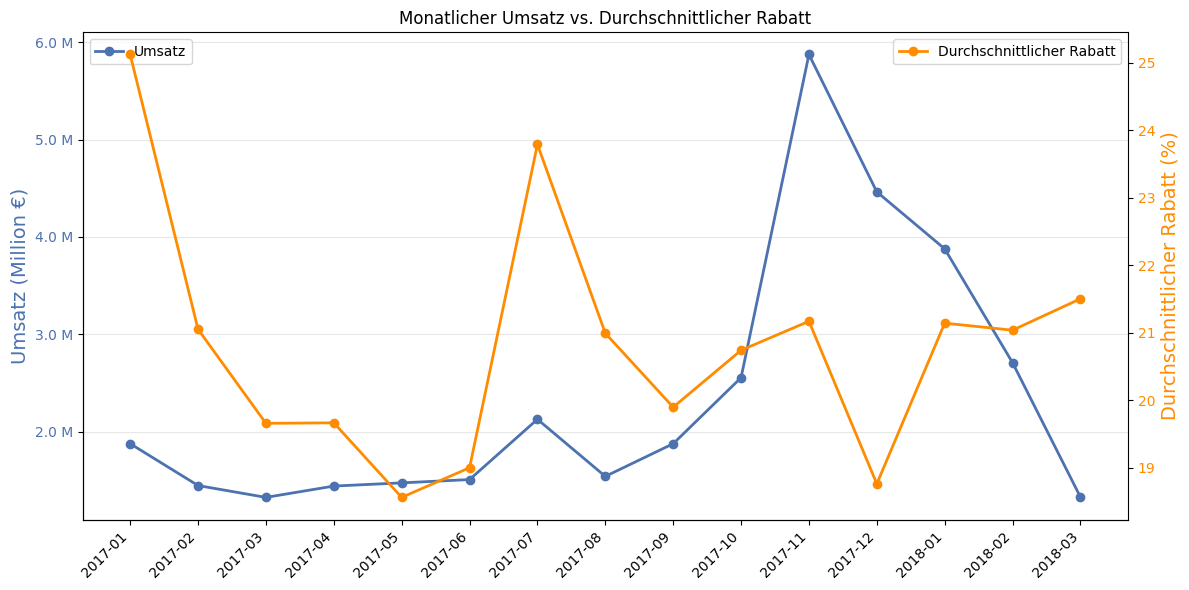

In [57]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Monthly revenue
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["unit_price_total"]
      .sum()
      .reset_index()
)

# Monthly average discount
monthly_discount = (
    df.groupby(df["date"].dt.to_period("M"))["discount_pct"]
      .mean()
      .reset_index()
)

# Convert Period to string
monthly_revenue["date"] = monthly_revenue["date"].astype(str)
monthly_discount["date"] = monthly_discount["date"].astype(str)

# Plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue
ax1.plot(
    monthly_revenue["date"],
    monthly_revenue["unit_price_total"],
    marker="o",
    linewidth=2,
    color="#4C72B0",
    label="Umsatz"
)

ax1.set_ylabel("Umsatz (Million €)", color="#4C72B0",fontsize=14)

# Format axis without 1e6
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1e6:.1f} M")
)

ax1.tick_params(axis="y", labelcolor="#4C72B0")

# Discount
ax2 = ax1.twinx()

ax2.plot(
    monthly_discount["date"],
    monthly_discount["discount_pct"],
    marker="o",
    linewidth=2,
    color="#FF8C00",
    label="Durchschnittlicher Rabatt"
)

ax2.set_ylabel("Durchschnittlicher Rabatt (%)", color="#FF8C00",fontsize=14)
ax2.tick_params(axis="y", labelcolor="#FF8C00")

# Title
plt.title("Monatlicher Umsatz vs. Durchschnittlicher Rabatt")

# Rotate x labels
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Grid
ax1.grid(axis="y", alpha=0.3)

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")


ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


plt.tight_layout()
plt.show()

### Conclusion

Almost all of the company's revenue comes from discounted sales.

Discounts were consistently used throughout the analyzed period and appear to be an important part of Eniac's pricing strategy.

97.3% of products were sold at a discount.
€33.6 million of the €35.4 million in revenue came from discounted products.
The biggest spike in sales occurred in November–December.
The average discount size was fairly stable (~20%), meaning the company did not increase discounts during peak sales.

## Are discounts beneficial?
 Yes, the analysis suggests that discounts have a positive impact on sales and revenue.